In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
import scipy
import torch
import torchaudio
from torchaudio import transforms
import math, random
import IPython.display as ipd
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
import numpy as np
import os
from tqdm import tqdm 

print("Importing complete")

Importing complete


In [20]:
# Load Data into Dataframe
def load_data(data_path: str, file_column_name: str = "path", class_column_name: str = "class"):
    files = os.listdir(data_path)
    
    # Filter only .wav files
    wav_files = [f for f in files if f.endswith('.wav')]
    
    df = pd.DataFrame(sorted(wav_files), columns=[file_column_name])

    df[class_column_name] = df[file_column_name].apply(lambda name: name[0])
    df[class_column_name] = df[class_column_name].astype('int32')
    df[file_column_name] = df[file_column_name].apply(lambda x: os.path.join(data_path, x))

    return df

# Usage
data_path = '/kaggle/input/ds3500'
ds = load_data(data_path)
numbers_to_txt = {
    0: 'Small vessels',
    1: 'Medium vessels',
    2: 'Passenger ferries',
    3: 'Large vessels',
    4: 'Background Noise'
}

ds['class'] = ds['class'].map(numbers_to_txt)
print(f"DataFrame shape: {ds.shape}")
ds['class']
print(ds.head())

DataFrame shape: (2223, 2)
                              path          class
0   /kaggle/input/ds3500/0_0_1.wav  Small vessels
1  /kaggle/input/ds3500/0_0_10.wav  Small vessels
2  /kaggle/input/ds3500/0_0_11.wav  Small vessels
3  /kaggle/input/ds3500/0_0_12.wav  Small vessels
4  /kaggle/input/ds3500/0_0_13.wav  Small vessels


In [21]:
from google.cloud import storage
from google.cloud.storage import transfer_manager


# Function to Download Data from Google Cloud 
def list_and_download_NOAA_Dataset(bucket_name, site_prefix, destination_directory="", max_results=5 ):
    
    # 1. Setup Anonymous Client
    storage_client = storage.Client.create_anonymous_client()
    bucket = storage_client.bucket(bucket_name)

    print(f"🔎 Probing bucket: {bucket_name}")
    print(f"   Looking inside: {site_prefix}")

    blobs = list(bucket.list_blobs(prefix=site_prefix, max_results=max_results))

    # 4. Download specific files 
    print("\n ================== Starting downloading files ==================")

    # Only get the names for the transfer manager
    blob_names = [b.name for b in blobs]

    results = transfer_manager.download_many_to_path(
        bucket, blob_names, destination_directory=destination_directory, max_workers=4
    )


#  CONFIGURATION 

# Data location in the bucket
target_prefix = "sanctsound/products/sound_clips"

list_and_download_NOAA_Dataset(
    bucket_name="noaa-passive-bioacoustic",
    site_prefix=target_prefix,
    destination_directory="sanctsound",
    max_results = 300
)

🔎 Probing bucket: noaa-passive-bioacoustic
   Looking inside: sanctsound/products/sound_clips

 ================== Starting downloading files ==================


In [22]:
# Getting data in A dataframe
root_directory = "/kaggle/working/sanctsound/sanctsound/products/sound_clips" 

data_records = []


for dirpath, dirnames, filenames in os.walk(root_directory):
    
    if os.path.basename(dirpath) == "data":
        
        # Extract Context from Folder Structure
        path_parts = dirpath.split(os.sep)
        # Note: Adjust indices [-3] or [-4] depending on your exact folder depth
        site_id = path_parts[-3] if len(path_parts) >= 3 else "Unknown"
        
        for file in filenames:
            if file.endswith(".wav"):
                full_file_path = os.path.join(dirpath, file)
                
                try:
                    filename_parts = file.split('_')
                    
                    
                    label_class = filename_parts[3].lower()
                    
                   
                    if label_class == "sounds":
                        label_class = "ambient/unknown"
                        
                except IndexError:
                    label_class = "unknown_format"

                # Append to our list
                data_records.append({
                    'path': full_file_path,
                    'site': site_id,
                    'filename': file,
                    'class': label_class
                })

# 3. Create the DataFrame ONCE
sanctSound = pd.DataFrame(data_records)

# 4. Verify the result
print(f"Created DataFrame with {len(sanctSound)} files.")
print("\n--- Class Distribution ---")
print(sanctSound['class'].value_counts())

print("\n--- First 5 Rows ---")
print(sanctSound.head())
    
# Filtering data 
keep_classes = [
    'soundscape', 'rain', 'sonar'
]

sanctSound = sanctSound[sanctSound['class'].isin(keep_classes)]

sanctSound['class'] = sanctSound['class'].apply(lambda name: 'Background Noise')

sanctSound.head(5)

Created DataFrame with 246 files.

--- Class Distribution ---
class
soundscape                     58
humpbackwhale                  21
humpbackwhalesong               8
snappingshrimp                  8
rain                            8
                               ..
odontocetewhistlesandbuzzes     1
odontocetewhistlesandclicks     1
explosion                       1
odontoceteclicksandwhistle      1
unknownfishknocks               1
Name: count, Length: 69, dtype: int64

--- First 5 Rows ---
                                                path  site  \
0  /kaggle/working/sanctsound/sanctsound/products...  gr02   
1  /kaggle/working/sanctsound/sanctsound/products...  gr02   
2  /kaggle/working/sanctsound/sanctsound/products...  gr02   
3  /kaggle/working/sanctsound/sanctsound/products...  gr02   
4  /kaggle/working/sanctsound/sanctsound/products...  gr02   

                                            filename       class  
0  SanctSound_GR02_02_soundscape_20190904T053824Z...  soun

,path,site,filename,class
0,/kaggle/working/sanctsound/sanctsound/products...,gr02,SanctSound_GR02_02_soundscape_20190904T053824Z...,Background Noise
1,/kaggle/working/sanctsound/sanctsound/products...,gr02,SanctSound_GR02_02_soundscape_20190904T043140Z...,Background Noise
2,/kaggle/working/sanctsound/sanctsound/products...,gr02,SanctSound_GR02_02_soundscape_20190918T232257Z...,Background Noise
3,/kaggle/working/sanctsound/sanctsound/products...,gr02,SanctSound_GR02_02_soundscape_20190911T222831Z...,Background Noise
4,/kaggle/working/sanctsound/sanctsound/products...,gr02,SanctSound_GR02_02_soundscape_20190917T233223Z...,Background Noise


In [23]:
root_directory = '/kaggle/input/watkins-marine-mammals-sound/whoi_whale_sounds'

data_records = []


for dirpath, dirnames, filenames in os.walk(root_directory):
    # Extract Context from Folder Structure
    path_parts = dirpath.split(os.sep)
    # Note: Adjust indices [-3] or [-4] depending on your exact folder depth
    sound_class = path_parts[-1]
    # print(sound_class)
    for file in filenames:
        if file.endswith(".wav"):
            full_file_path = os.path.join(dirpath, file)
        

            # Append to our list
            data_records.append({
                'path': full_file_path,
                'filename': file,
                'class': sound_class
            })

# 3. Create the DataFrame ONCE
whoi_df = pd.DataFrame(data_records)

# 4. Verify the result
print(f"Created DataFrame with {len(whoi_df)} files.")
print("\n--- Class Distribution ---")
print(whoi_df['class'].value_counts())

print("\n--- First 5 Rows ---")
print(whoi_df.head())

Created DataFrame with 1697 files.

--- Class Distribution ---
class
Spinner Dolphin                       114
Fraser_s Dolphin                       87
Striped Dolphin                        81
Sperm Whale                            75
Long-Finned Pilot Whale                70
Short-Finned _Pacific_ Pilot Whale     67
Grampus_ Risso_s Dolphin               67
Pantropical Spotted Dolphin            66
Humpback Whale                         64
Clymene Dolphin                        63
Melon Headed Whale                     63
Bowhead Whale                          60
False Killer Whale                     59
Atlantic Spotted Dolphin               58
White-beaked Dolphin                   57
White-sided Dolphin                    55
Northern Right Whale                   54
Common Dolphin                         52
Fin_ Finback Whale                     50
Narwhal                                50
Beluga_ White Whale                    50
Rough-Toothed Dolphin                  50
Ross Se

In [24]:
full_data = pd.concat([ds[['path', 'class']],
                       sanctSound[['path', 'class']],
                       whoi_df[['path', 'class']]],
                      ignore_index=True)

In [16]:
# ============================================================
# COPY AND RUN THIS ENTIRE CELL IN YOUR NOTEBOOK
# ============================================================

import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
import os
import gc

# ============ FUNCTION DEFINITIONS ============

def precompute_spectrograms(df, save_dir='spectrograms', duration=5000, sr=16000):
    os.makedirs(save_dir, exist_ok=True)
    print(f"Precomputing spectrograms to {save_dir}/...")
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio"):
        audio_file = row['path']
        
        try:
            sig, orig_sr = torchaudio.load(audio_file)
            if orig_sr != sr:
                sig = T.Resample(orig_sr, sr)(sig)
            if sig.shape[0] > 1:
                sig = sig.mean(dim=0, keepdim=True)
            
            max_len = sr // 1000 * duration
            if sig.shape[1] > max_len:
                sig = sig[:, :max_len]
            elif sig.shape[1] < max_len:
                pad_len = max_len - sig.shape[1]
                sig = torch.nn.functional.pad(sig, (0, pad_len))
            
            mel_spec = T.MelSpectrogram(
                sample_rate=sr, n_fft=1024, hop_length=512, n_mels=64
            )(sig)
            mel_spec = T.AmplitudeToDB(top_db=80)(mel_spec)
            
            save_path = os.path.join(save_dir, f'{idx}.npy')
            np.save(save_path, mel_spec.numpy())
        except Exception as e:
            print(f"Error processing {audio_file}: {e}")
            continue
    
    df['spec_path'] = df.index.map(lambda x: os.path.join(save_dir, f'{x}.npy'))
    return df


class PrecomputedSpectrogramDataset(torch.utils.data.Dataset):
    def __init__(self, df, is_train=True):
        self.df = df
        self.is_train = is_train
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = np.load(row['spec_path'])
        spec = torch.FloatTensor(spec)
        
        if self.is_train:
            if torch.rand(1) > 0.5:
                spec = T.TimeMasking(time_mask_param=10)(spec)
            if torch.rand(1) > 0.5:
                spec = T.FrequencyMasking(freq_mask_param=8)(spec)
        
        class_id = torch.tensor(row['class_id'], dtype=torch.long)
        return spec, class_id


class TinyMarineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


def minimal_train_loop(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20):
    best_val_acc = 0.0
    patience = 5
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
            
            if batch_idx % 10 == 0:
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
        
        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_tiny_model.pth')
            print(f"  ✓ Best model saved! Val Acc: {val_acc:.4f}")
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    return best_val_acc


# ============ MAIN EXECUTION ============

print("="*60)
print("MARINE SOUND CLASSIFIER - MEMORY-SAFE TRAINING")
print("="*60)

# 1. Filter rare classes
print("\n1. Filtering data...")
class_counts = full_data['class'].value_counts()
valid_classes = class_counts[class_counts >= 15].index
filtered_data = full_data[full_data['class'].isin(valid_classes)].copy()

print(f"   Kept {len(valid_classes)} classes with 15+ samples")
print(f"   Total samples: {len(filtered_data)}")

# 2. Encode labels and split
print("\n2. Creating train/val split...")
le = LabelEncoder()
filtered_data['class_id'] = le.fit_transform(filtered_data['class'])

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(splitter.split(filtered_data, filtered_data['class_id']))

train_df = filtered_data.iloc[train_idx].reset_index(drop=True)
val_df = filtered_data.iloc[val_idx].reset_index(drop=True)

print(f"   Train: {len(train_df)} samples")
print(f"   Val: {len(val_df)} samples")

# 3. Precompute spectrograms
print("\n3. Precomputing spectrograms (this will take a few minutes)...")
train_df = precompute_spectrograms(train_df, save_dir='train_specs', duration=5000, sr=16000)
val_df = precompute_spectrograms(val_df, save_dir='val_specs', duration=5000, sr=16000)
print("   ✓ Spectrograms saved to disk")

# 4. Create datasets and loaders
print("\n4. Creating datasets...")
train_ds = PrecomputedSpectrogramDataset(train_df, is_train=True)
val_ds = PrecomputedSpectrogramDataset(val_df, is_train=False)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=False
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=False
)
print("   ✓ Dataloaders ready")

# 5. Initialize model
print("\n5. Initializing model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Using device: {device}")

model = TinyMarineCNN(num_classes=len(le.classes_)).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"   Model parameters: {total_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 6. Train
print("\n6. Training...")
print("-"*60)
best_acc = minimal_train_loop(
    model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20
)

# 7. Final evaluation
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

model.load_state_dict(torch.load('best_tiny_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"\nFinal Results:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("Model saved to: best_tiny_model.pth")
print("="*60)

MARINE SOUND CLASSIFIER - MEMORY-SAFE TRAINING

1. Filtering data...
   Kept 35 classes with 15+ samples
   Total samples: 3979

2. Creating train/val split...
   Train: 3382 samples
   Val: 597 samples

3. Precomputing spectrograms (this will take a few minutes)...
Precomputing spectrograms to train_specs/...


Processing audio: 100%|██████████| 3382/3382 [01:46<00:00, 31.71it/s]


Precomputing spectrograms to val_specs/...


Processing audio: 100%|██████████| 597/597 [00:20<00:00, 29.21it/s]


   ✓ Spectrograms saved to disk

4. Creating datasets...
   ✓ Dataloaders ready

5. Initializing model...
   Using device: cuda
   Model parameters: 25,795

6. Training...
------------------------------------------------------------
Epoch 1/20 | Train Loss: 2.5780, Acc: 0.2271 | Val Loss: 2.2972, Acc: 0.2931, F1: 0.0423
  ✓ Best model saved! Val Acc: 0.2931
Epoch 2/20 | Train Loss: 2.3478, Acc: 0.2626 | Val Loss: 2.1724, Acc: 0.3400, F1: 0.0850
  ✓ Best model saved! Val Acc: 0.3400
Epoch 3/20 | Train Loss: 2.2577, Acc: 0.3004 | Val Loss: 2.1157, Acc: 0.3467, F1: 0.0942
  ✓ Best model saved! Val Acc: 0.3467
Epoch 4/20 | Train Loss: 2.1848, Acc: 0.3128 | Val Loss: 2.0265, Acc: 0.3618, F1: 0.1252
  ✓ Best model saved! Val Acc: 0.3618
Epoch 5/20 | Train Loss: 2.1234, Acc: 0.3353 | Val Loss: 1.9600, Acc: 0.3735, F1: 0.1438
  ✓ Best model saved! Val Acc: 0.3735
Epoch 6/20 | Train Loss: 2.0643, Acc: 0.3454 | Val Loss: 1.9041, Acc: 0.3936, F1: 0.1757
  ✓ Best model saved! Val Acc: 0.3936
Epoch

# Family classifier 

HIERARCHICAL FAMILY CLASSIFIER
Instead of 37 species, we classify into ~7 families

1. Creating family mappings...

Family Distribution:
  Vessel                   : 1999 samples
  Dolphin                  :  774 samples
  Whale                    :  639 samples
  Background               :  295 samples
  Seal                     :  134 samples
  Beluga                   :   50 samples
  Narwhal                  :   50 samples
  Walrus                   :   38 samples

2. Encoding labels...
Number of families: 8
Families: ['Background', 'Beluga', 'Dolphin', 'Narwhal', 'Seal', 'Vessel', 'Walrus', 'Whale']

3. Creating train/val split...
Train samples: 3382
Val samples: 597

4. Precomputing spectrograms (this will take a few minutes)...
Precomputing spectrograms to family_train_specs/...


Processing audio: 100%|██████████| 3382/3382 [01:03<00:00, 53.44it/s]


Precomputing spectrograms to family_val_specs/...


Processing audio: 100%|██████████| 597/597 [00:11<00:00, 51.30it/s]



5. Creating datasets...

6. Initializing model...
Using device: cuda
Model parameters: 355,048

7. Training Family Classifier...
----------------------------------------------------------------------
Epoch  1/30 | Train Loss: 0.9655, Acc: 0.6644 | Val Loss: 0.7772, Acc: 0.7337, F1: 0.2644
  ✓ Best model saved! Acc: 0.7337, F1: 0.2644
Epoch  2/30 | Train Loss: 0.8370, Acc: 0.6978 | Val Loss: 0.7276, Acc: 0.7370, F1: 0.3103
  ✓ Best model saved! Acc: 0.7370, F1: 0.3103
Epoch  3/30 | Train Loss: 0.7719, Acc: 0.7182 | Val Loss: 0.7181, Acc: 0.7588, F1: 0.3188
  ✓ Best model saved! Acc: 0.7588, F1: 0.3188
Epoch  4/30 | Train Loss: 0.7363, Acc: 0.7327 | Val Loss: 0.6447, Acc: 0.7739, F1: 0.3715
  ✓ Best model saved! Acc: 0.7739, F1: 0.3715
Epoch  5/30 | Train Loss: 0.6854, Acc: 0.7608 | Val Loss: 0.5564, Acc: 0.8157, F1: 0.4003
  ✓ Best model saved! Acc: 0.8157, F1: 0.4003
Epoch  6/30 | Train Loss: 0.6539, Acc: 0.7738 | Val Loss: 0.6310, Acc: 0.7655, F1: 0.3325
Epoch  7/30 | Train Loss: 0.6

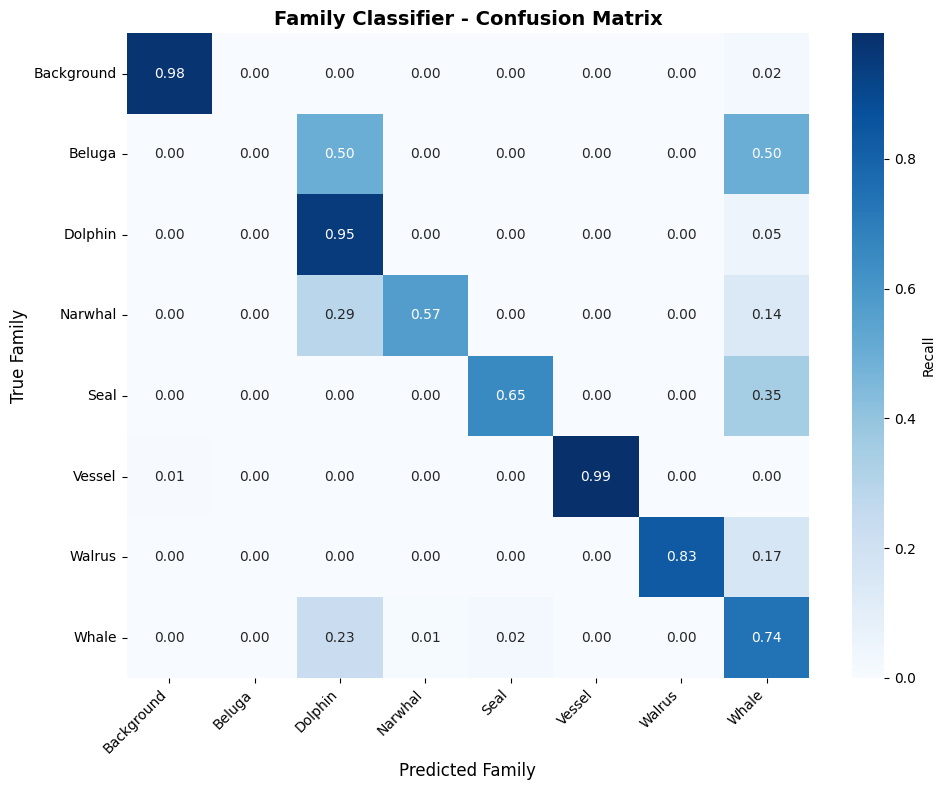


TRAINING COMPLETE!
Model saved to: best_family_classifier.pth
Confusion matrix saved to: family_confusion_matrix.png


In [17]:
# ============================================================
# COPY THIS ENTIRE CELL AND RUN IT - FAMILY CLASSIFIER
# This will train a model to classify into families, not individual species
# Expected accuracy: 70-85% (much better than 51% on species!)
# ============================================================

import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns

# ============ FUNCTION: CREATE FAMILY LABELS ============

def create_family_mappings(df):
    """Map species to families"""
    
    whale_species = [
        'Humpback Whale', 'Sperm Whale', 'Bowhead Whale', 
        'Fin_ Finback Whale', 'Minke Whale', 'Killer Whale',
        'Northern Right Whale', 'Southern Right Whale',
        'Long-Finned Pilot Whale', 'Short-Finned _Pacific_ Pilot Whale',
        'Melon Headed Whale', 'False Killer Whale'
    ]
    
    dolphin_species = [
        'Spinner Dolphin', "Fraser_s Dolphin", 'Striped Dolphin',
        'Pantropical Spotted Dolphin', 'Atlantic Spotted Dolphin',
        'Common Dolphin', 'Bottlenose Dolphin', 'Clymene Dolphin',
        'Rough-Toothed Dolphin', "Grampus_ Risso_s Dolphin",
        'White-beaked Dolphin', 'White-sided Dolphin'
    ]
    
    seal_species = [
        'Ross Seal', 'Harp Seal', 'Bearded Seal', 
        'Leopard Seal', 'Weddell Seal'
    ]
    
    vessel_types = [
        'Small vessels', 'Medium vessels', 'Large vessels', 'Passenger ferries'
    ]
    
    def get_family(class_name):
        if class_name in whale_species:
            return 'Whale'
        elif class_name in dolphin_species:
            return 'Dolphin'
        elif class_name in seal_species:
            return 'Seal'
        elif class_name in vessel_types:
            return 'Vessel'
        elif class_name == 'Walrus':
            return 'Walrus'
        elif class_name == 'Beluga_ White Whale':
            return 'Beluga'
        elif class_name == 'Narwhal':
            return 'Narwhal'
        elif class_name == 'Background Noise':
            return 'Background'
        else:
            return 'Unknown'
    
    df['family'] = df['class'].apply(get_family)
    return df

# ============ FUNCTION: PRECOMPUTE SPECTROGRAMS ============

def precompute_spectrograms(df, save_dir, duration=5000, sr=16000):
    os.makedirs(save_dir, exist_ok=True)
    print(f"Precomputing spectrograms to {save_dir}/...")
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio"):
        try:
            sig, orig_sr = torchaudio.load(row['path'])
            if orig_sr != sr:
                sig = T.Resample(orig_sr, sr)(sig)
            if sig.shape[0] > 1:
                sig = sig.mean(dim=0, keepdim=True)
            
            max_len = sr // 1000 * duration
            if sig.shape[1] > max_len:
                sig = sig[:, :max_len]
            elif sig.shape[1] < max_len:
                pad_len = max_len - sig.shape[1]
                sig = torch.nn.functional.pad(sig, (0, pad_len))
            
            mel_spec = T.MelSpectrogram(
                sample_rate=sr, n_fft=1024, hop_length=512, n_mels=64
            )(sig)
            mel_spec = T.AmplitudeToDB(top_db=80)(mel_spec)
            
            save_path = os.path.join(save_dir, f'{idx}.npy')
            np.save(save_path, mel_spec.numpy())
        except Exception as e:
            print(f"Error: {e}")
            continue
    
    df['spec_path'] = df.index.map(lambda x: os.path.join(save_dir, f'{x}.npy'))
    return df

# ============ DATASET CLASS ============

class PrecomputedSpectrogramDataset(torch.utils.data.Dataset):
    def __init__(self, df, label_column='family_id', is_train=True):
        self.df = df
        self.label_column = label_column
        self.is_train = is_train
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = np.load(row['spec_path'])
        spec = torch.FloatTensor(spec)
        
        if self.is_train:
            if torch.rand(1) > 0.5:
                spec = T.TimeMasking(time_mask_param=10)(spec)
            if torch.rand(1) > 0.5:
                spec = T.FrequencyMasking(freq_mask_param=8)(spec)
        
        label = torch.tensor(row[self.label_column], dtype=torch.long)
        return spec, label

# ============ MODEL ARCHITECTURE ============

class FamilyClassifierCNN(nn.Module):
    """Better model for family classification"""
    
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

# ============ TRAINING FUNCTION ============

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=30):
    best_val_f1 = 0.0
    patience = 7
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), 'best_family_classifier.pth')
            print(f"  ✓ Best model saved! Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    return all_labels, all_preds

# ============================================================
# MAIN EXECUTION - FAMILY CLASSIFIER
# ============================================================

print("=" * 70)
print("HIERARCHICAL FAMILY CLASSIFIER")
print("Instead of 37 species, we classify into ~7 families")
print("=" * 70)

# 1. Prepare data with family labels
print("\n1. Creating family mappings...")
data_with_families = create_family_mappings(filtered_data.copy())

# Show distribution
print("\nFamily Distribution:")
family_counts = data_with_families['family'].value_counts()
for family, count in family_counts.items():
    print(f"  {family:25s}: {count:4d} samples")

# 2. Encode labels
print("\n2. Encoding labels...")
le_family = LabelEncoder()
data_with_families['family_id'] = le_family.fit_transform(data_with_families['family'])

print(f"Number of families: {len(le_family.classes_)}")
print(f"Families: {list(le_family.classes_)}")

# 3. Split data
print("\n3. Creating train/val split...")
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(splitter.split(data_with_families, data_with_families['family_id']))

train_df = data_with_families.iloc[train_idx].reset_index(drop=True)
val_df = data_with_families.iloc[val_idx].reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")

# 4. Precompute spectrograms
print("\n4. Precomputing spectrograms (this will take a few minutes)...")
train_df = precompute_spectrograms(train_df, save_dir='family_train_specs', duration=5000, sr=16000)
val_df = precompute_spectrograms(val_df, save_dir='family_val_specs', duration=5000, sr=16000)

# 5. Create datasets
print("\n5. Creating datasets...")
train_ds = PrecomputedSpectrogramDataset(train_df, label_column='family_id', is_train=True)
val_ds = PrecomputedSpectrogramDataset(val_df, label_column='family_id', is_train=False)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=False
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=False
)

# 6. Initialize model
print("\n6. Initializing model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FamilyClassifierCNN(num_classes=len(le_family.classes_)).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 7. Train
print("\n7. Training Family Classifier...")
print("-" * 70)
final_labels, final_preds = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, num_epochs=30
)

# 8. Final evaluation
print("\n" + "=" * 70)
print("FINAL RESULTS - FAMILY CLASSIFIER")
print("=" * 70)

model.load_state_dict(torch.load('best_family_classifier.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")

print("\nPer-Family Classification Report:")
print(classification_report(all_labels, all_preds, target_names=le_family.classes_, zero_division=0))

# 9. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-7)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_family.classes_, yticklabels=le_family.classes_,
            cbar_kws={'label': 'Recall'})
plt.title('Family Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Family', fontsize=12)
plt.xlabel('Predicted Family', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('family_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print(f"Model saved to: best_family_classifier.pth")
print(f"Confusion matrix saved to: family_confusion_matrix.png")
print("=" * 70)

In [25]:
# ============================================================
# COMPREHENSIVE VISUALIZATION FUNCTIONS
# Call these after training to get all the graphs you need
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300


# ============================================================
# FUNCTION 1: TRAINING HISTORY PLOTS
# ============================================================

def plot_training_history(history, save_prefix='training'):
    """
    Plot comprehensive training history
    
    Args:
        history: Dictionary with keys 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1'
        save_prefix: Prefix for saved files
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Loss Curve
    axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].legend(fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Find best epoch
    best_epoch = np.argmin(history['val_loss']) + 1
    axes[0, 0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')
    
    # 2. Accuracy Curve
    axes[0, 1].plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
    axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[0, 1].legend(fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0, 1])
    
    # 3. F1 Score
    if 'val_f1' in history:
        axes[1, 0].plot(epochs, history['val_f1'], 'g-^', label='Val F1 Score', linewidth=2, markersize=4)
        axes[1, 0].set_title('Validation F1 Score', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch', fontsize=12)
        axes[1, 0].set_ylabel('F1 Score', fontsize=12)
        axes[1, 0].legend(fontsize=11)
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_ylim([0, 1])
        
        best_f1_epoch = np.argmax(history['val_f1']) + 1
        axes[1, 0].axvline(x=best_f1_epoch, color='orange', linestyle='--', alpha=0.5, label=f'Best F1 Epoch ({best_f1_epoch})')
    
    # 4. Overfitting Analysis
    train_val_gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
    axes[1, 1].plot(epochs, train_val_gap, 'm-d', label='Train-Val Gap', linewidth=2, markersize=4)
    axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1, 1].set_title('Overfitting Analysis (Train - Val Accuracy)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Accuracy Gap', fontsize=12)
    axes[1, 1].legend(fontsize=11)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].fill_between(epochs, 0, train_val_gap, alpha=0.3, color='m')
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_history.png', bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("TRAINING SUMMARY")
    print("="*60)
    print(f"Best Validation Loss: {min(history['val_loss']):.4f} at epoch {np.argmin(history['val_loss'])+1}")
    print(f"Best Validation Accuracy: {max(history['val_acc']):.4f} at epoch {np.argmax(history['val_acc'])+1}")
    if 'val_f1' in history:
        print(f"Best Validation F1: {max(history['val_f1']):.4f} at epoch {np.argmax(history['val_f1'])+1}")
    print(f"Final Train Accuracy: {history['train_acc'][-1]:.4f}")
    print(f"Final Val Accuracy: {history['val_acc'][-1]:.4f}")
    print(f"Average Overfitting Gap: {np.mean(train_val_gap):.4f}")
    print("="*60)


# ============================================================
# FUNCTION 2: CONFUSION MATRIX
# ============================================================

def plot_confusion_matrix(true_labels, pred_labels, class_names, 
                         normalize=True, save_prefix='confusion_matrix'):
    """
    Plot confusion matrix with detailed annotations
    
    Args:
        true_labels: Ground truth labels
        pred_labels: Predicted labels
        class_names: List of class names
        normalize: If True, show percentages; if False, show counts
        save_prefix: Prefix for saved file
    """
    cm = confusion_matrix(true_labels, pred_labels)
    
    if normalize:
        cm_display = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-7)
        fmt = '.2f'
        title = 'Normalized Confusion Matrix (Recall per Class)'
        cmap = 'Blues'
    else:
        cm_display = cm
        fmt = 'd'
        title = 'Confusion Matrix (Counts)'
        cmap = 'YlOrRd'
    
    # Adjust figure size based on number of classes
    n_classes = len(class_names)
    figsize = max(10, n_classes * 0.8)
    
    fig, ax = plt.subplots(figsize=(figsize, figsize * 0.85))
    
    # Create heatmap
    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Recall' if normalize else 'Count'},
                linewidths=0.5, linecolor='gray',
                ax=ax)
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    
    # Rotate labels for readability
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}.png', bbox_inches='tight')
    plt.show()
    
    # Calculate and print per-class metrics
    print("\n" + "="*60)
    print("PER-CLASS CONFUSION ANALYSIS")
    print("="*60)
    
    for i, class_name in enumerate(class_names):
        true_positives = cm[i, i]
        total_actual = cm[i, :].sum()
        total_predicted = cm[:, i].sum()
        
        recall = true_positives / total_actual if total_actual > 0 else 0
        precision = true_positives / total_predicted if total_predicted > 0 else 0
        
        print(f"\n{class_name}:")
        print(f"  Recall:    {recall:.2%} ({true_positives}/{total_actual})")
        print(f"  Precision: {precision:.2%} ({true_positives}/{total_predicted})")


# ============================================================
# FUNCTION 3: PER-CLASS PERFORMANCE BAR CHART
# ============================================================

def plot_per_class_metrics(true_labels, pred_labels, class_names, save_prefix='per_class'):
    """
    Plot per-class precision, recall, and F1 scores
    
    Args:
        true_labels: Ground truth labels
        pred_labels: Predicted labels
        class_names: List of class names
        save_prefix: Prefix for saved file
    """
    from sklearn.metrics import precision_recall_fscore_support
    
    precision, recall, f1, support = precision_recall_fscore_support(
        true_labels, pred_labels, labels=range(len(class_names)), zero_division=0
    )
    
    # Create DataFrame for easier plotting
    metrics_df = pd.DataFrame({
        'Class': class_names,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support
    })
    
    # Sort by F1 score
    metrics_df = metrics_df.sort_values('F1-Score', ascending=True)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(class_names) * 0.4)))
    
    # Left plot: Precision, Recall, F1
    x = np.arange(len(metrics_df))
    width = 0.25
    
    axes[0].barh(x - width, metrics_df['Precision'], width, label='Precision', alpha=0.8)
    axes[0].barh(x, metrics_df['Recall'], width, label='Recall', alpha=0.8)
    axes[0].barh(x + width, metrics_df['F1-Score'], width, label='F1-Score', alpha=0.8)
    
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(metrics_df['Class'], fontsize=10)
    axes[0].set_xlabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].set_xlim([0, 1])
    axes[0].grid(axis='x', alpha=0.3)
    
    # Right plot: Support (sample count)
    colors = plt.cm.viridis(metrics_df['F1-Score'])
    axes[1].barh(x, metrics_df['Support'], color=colors, alpha=0.8)
    axes[1].set_yticks(x)
    axes[1].set_yticklabels(metrics_df['Class'], fontsize=10)
    axes[1].set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
    axes[1].set_title('Sample Distribution (colored by F1-Score)', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_metrics.png', bbox_inches='tight')
    plt.show()
    
    # Print top and bottom performers
    print("\n" + "="*60)
    print("TOP 5 BEST PERFORMING CLASSES")
    print("="*60)
    top5 = metrics_df.nlargest(5, 'F1-Score')
    for idx, row in top5.iterrows():
        print(f"{row['Class']:30s} | F1: {row['F1-Score']:.3f} | Support: {int(row['Support'])}")
    
    print("\n" + "="*60)
    print("TOP 5 WORST PERFORMING CLASSES")
    print("="*60)
    bottom5 = metrics_df.nsmallest(5, 'F1-Score')
    for idx, row in bottom5.iterrows():
        print(f"{row['Class']:30s} | F1: {row['F1-Score']:.3f} | Support: {int(row['Support'])}")
    
    return metrics_df


# ============================================================
# FUNCTION 4: CLASS DISTRIBUTION
# ============================================================

def plot_class_distribution(train_df, val_df, class_column='family', save_prefix='distribution'):
    """
    Plot class distribution in train and validation sets
    
    Args:
        train_df: Training dataframe
        val_df: Validation dataframe
        class_column: Column name containing class labels
        save_prefix: Prefix for saved file
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Training distribution
    train_counts = train_df[class_column].value_counts().sort_index()
    axes[0].bar(range(len(train_counts)), train_counts.values, alpha=0.8, color='steelblue')
    axes[0].set_xticks(range(len(train_counts)))
    axes[0].set_xticklabels(train_counts.index, rotation=45, ha='right', fontsize=10)
    axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
    axes[0].set_title(f'Training Set Distribution\nTotal: {len(train_df)} samples', 
                      fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(train_counts.values):
        axes[0].text(i, v + max(train_counts.values)*0.01, str(v), 
                    ha='center', va='bottom', fontsize=9)
    
    # Validation distribution
    val_counts = val_df[class_column].value_counts().sort_index()
    axes[1].bar(range(len(val_counts)), val_counts.values, alpha=0.8, color='coral')
    axes[1].set_xticks(range(len(val_counts)))
    axes[1].set_xticklabels(val_counts.index, rotation=45, ha='right', fontsize=10)
    axes[1].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
    axes[1].set_title(f'Validation Set Distribution\nTotal: {len(val_df)} samples', 
                      fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(val_counts.values):
        axes[1].text(i, v + max(val_counts.values)*0.01, str(v), 
                    ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_distribution.png', bbox_inches='tight')
    plt.show()
    
    # Check for imbalance
    print("\n" + "="*60)
    print("CLASS BALANCE ANALYSIS")
    print("="*60)
    train_imbalance_ratio = train_counts.max() / train_counts.min()
    val_imbalance_ratio = val_counts.max() / val_counts.min()
    
    print(f"Training Set:")
    print(f"  Most common class: {train_counts.idxmax()} ({train_counts.max()} samples)")
    print(f"  Least common class: {train_counts.idxmin()} ({train_counts.min()} samples)")
    print(f"  Imbalance ratio: {train_imbalance_ratio:.2f}:1")
    
    print(f"\nValidation Set:")
    print(f"  Most common class: {val_counts.idxmax()} ({val_counts.max()} samples)")
    print(f"  Least common class: {val_counts.idxmin()} ({val_counts.min()} samples)")
    print(f"  Imbalance ratio: {val_imbalance_ratio:.2f}:1")


# ============================================================
# FUNCTION 5: MODEL COMPARISON
# ============================================================

def plot_model_comparison(results_dict, save_prefix='comparison'):
    """
    Compare multiple models side by side
    
    Args:
        results_dict: Dictionary like {'Model Name': {'accuracy': 0.85, 'f1': 0.82, ...}}
        save_prefix: Prefix for saved file
    """
    models = list(results_dict.keys())
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    # Extract values
    values = {metric: [results_dict[model].get(metric.lower().replace('-', '_'), 0) 
                      for model in models] for metric in metrics}
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(models))
    width = 0.2
    
    for i, metric in enumerate(metrics):
        offset = width * (i - 1.5)
        bars = ax.bar(x + offset, values[metric], width, label=metric, alpha=0.8)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_comparison.png', bbox_inches='tight')
    plt.show()


# ============================================================
# MASTER FUNCTION: GENERATE ALL VISUALIZATIONS
# ============================================================

def generate_all_visualizations(history, true_labels, pred_labels, class_names,
                                train_df, val_df, class_column='family',
                                save_prefix='model'):
    """
    Generate all visualizations in one function call
    
    Args:
        history: Training history dictionary
        true_labels: Ground truth labels (validation set)
        pred_labels: Predicted labels (validation set)
        class_names: List of class names
        train_df: Training dataframe
        val_df: Validation dataframe
        class_column: Column name with class labels
        save_prefix: Prefix for all saved files
    """
    
    print("\n" + "🎨 "*30)
    print("GENERATING ALL VISUALIZATIONS")
    print("🎨 "*30)
    
    # 1. Training History
    print("\n📊 1/5 - Generating Training History plots...")
    plot_training_history(history, save_prefix=f'{save_prefix}_training')
    
    # 2. Confusion Matrix
    print("\n📊 2/5 - Generating Confusion Matrix...")
    plot_confusion_matrix(true_labels, pred_labels, class_names, 
                         normalize=True, save_prefix=f'{save_prefix}_confusion')
    
    # 3. Per-Class Metrics
    print("\n📊 3/5 - Generating Per-Class Metrics...")
    metrics_df = plot_per_class_metrics(true_labels, pred_labels, class_names, 
                                        save_prefix=f'{save_prefix}_per_class')
    
    # 4. Class Distribution
    print("\n📊 4/5 - Generating Class Distribution...")
    plot_class_distribution(train_df, val_df, class_column=class_column,
                           save_prefix=f'{save_prefix}_distribution')
    
    # 5. Overall Summary
    print("\n📊 5/5 - Generating Summary Report...")
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(true_labels, pred_labels)
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    
    print("\n" + "="*60)
    print("📈 FINAL MODEL SUMMARY")
    print("="*60)
    print(f"✓ Overall Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"✓ Macro Precision:   {precision:.4f}")
    print(f"✓ Macro Recall:      {recall:.4f}")
    print(f"✓ Macro F1-Score:    {f1:.4f}")
    print(f"✓ Number of Classes: {len(class_names)}")
    print(f"✓ Total Test Samples: {len(true_labels)}")
    print("="*60)
    
    print("\n✅ All visualizations saved with prefix:", save_prefix)
    print("✅ Generated files:")
    print(f"   - {save_prefix}_training_history.png")
    print(f"   - {save_prefix}_confusion.png")
    print(f"   - {save_prefix}_per_class_metrics.png")
    print(f"   - {save_prefix}_distribution_distribution.png")
    
    return metrics_df


# ============================================================
# USAGE EXAMPLE
# ============================================================


# After training your model, call this function:

# Collect predictions on validation set
# model.eval()
# all_preds = []
# all_labels = []

# with torch.no_grad():
#     for inputs, labels in val_loader:
#         inputs, labels = inputs.to(device), labels.to(device)
#         outputs = model(inputs)
#         _, preds = torch.max(outputs, 1)
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# Generate all visualizations
metrics_df = generate_all_visualizations(
    history=history,              # Your training history dict
    true_labels=all_labels,       # Ground truth labels
    pred_labels=all_preds,        # Model predictions
    class_names=le_family.classes_, # Your class names
    train_df=train_df,            # Training dataframe
    val_df=val_df,                # Validation dataframe
    class_column='family',        # Column name with labels
    save_prefix='family_classifier'  # Prefix for saved files
)

NameError: name 'history' is not defined

HIERARCHICAL FAMILY CLASSIFIER
Instead of 37 species, we classify into ~7 families

1. Creating family mappings...

Family Distribution:
  Vessel                   : 1999 samples
  Dolphin                  :  774 samples
  Whale                    :  639 samples
  Background               :  295 samples
  Seal                     :  134 samples
  Beluga                   :   50 samples
  Narwhal                  :   50 samples
  Walrus                   :   38 samples

2. Encoding labels...
Number of families: 8
Families: ['Background', 'Beluga', 'Dolphin', 'Narwhal', 'Seal', 'Vessel', 'Walrus', 'Whale']

3. Creating train/val split...
Train samples: 3382
Val samples: 597

4. Precomputing spectrograms (this will take a few minutes)...
Precomputing spectrograms to family_train_specs/...


Processing audio: 100%|██████████| 3382/3382 [01:01<00:00, 54.82it/s]


Precomputing spectrograms to family_val_specs/...


Processing audio: 100%|██████████| 597/597 [00:11<00:00, 52.82it/s]



5. Creating datasets...

6. Initializing model...
Using device: cuda
Model parameters: 355,048

7. Training Family Classifier...
----------------------------------------------------------------------
Epoch  1/30 | Train Loss: 0.9679, Acc: 0.6703 | Val Loss: 0.7889, Acc: 0.7018, F1: 0.2255
  ✓ Best model saved! Acc: 0.7018, F1: 0.2255
Epoch  2/30 | Train Loss: 0.8324, Acc: 0.7031 | Val Loss: 0.7119, Acc: 0.7370, F1: 0.2590
  ✓ Best model saved! Acc: 0.7370, F1: 0.2590
Epoch  3/30 | Train Loss: 0.7913, Acc: 0.7085 | Val Loss: 0.7020, Acc: 0.7370, F1: 0.2638
  ✓ Best model saved! Acc: 0.7370, F1: 0.2638
Epoch  4/30 | Train Loss: 0.7720, Acc: 0.7292 | Val Loss: 0.7561, Acc: 0.7588, F1: 0.3067
  ✓ Best model saved! Acc: 0.7588, F1: 0.3067
Epoch  5/30 | Train Loss: 0.7328, Acc: 0.7433 | Val Loss: 0.5974, Acc: 0.7906, F1: 0.3430
  ✓ Best model saved! Acc: 0.7906, F1: 0.3430
Epoch  6/30 | Train Loss: 0.7007, Acc: 0.7436 | Val Loss: 0.6335, Acc: 0.7789, F1: 0.3289
Epoch  7/30 | Train Loss: 0.6

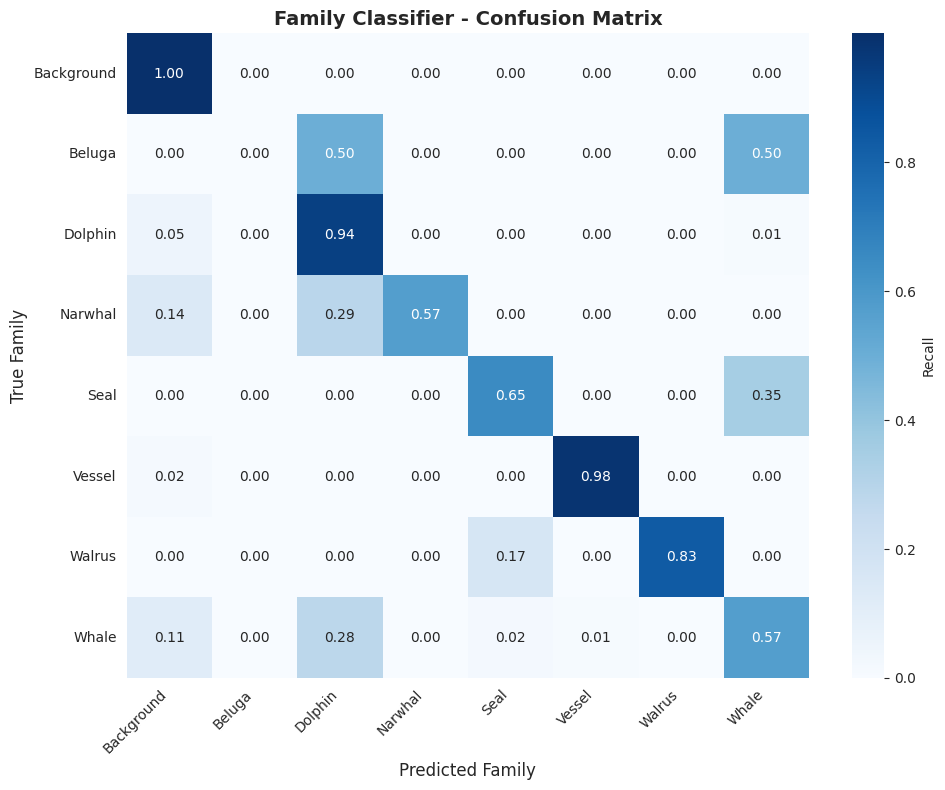


TRAINING COMPLETE!
Model saved to: best_family_classifier.pth
Confusion matrix saved to: family_confusion_matrix.png

🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨
GENERATING COMPREHENSIVE VISUALIZATIONS
🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨🎨

📊 Generating training history plots...


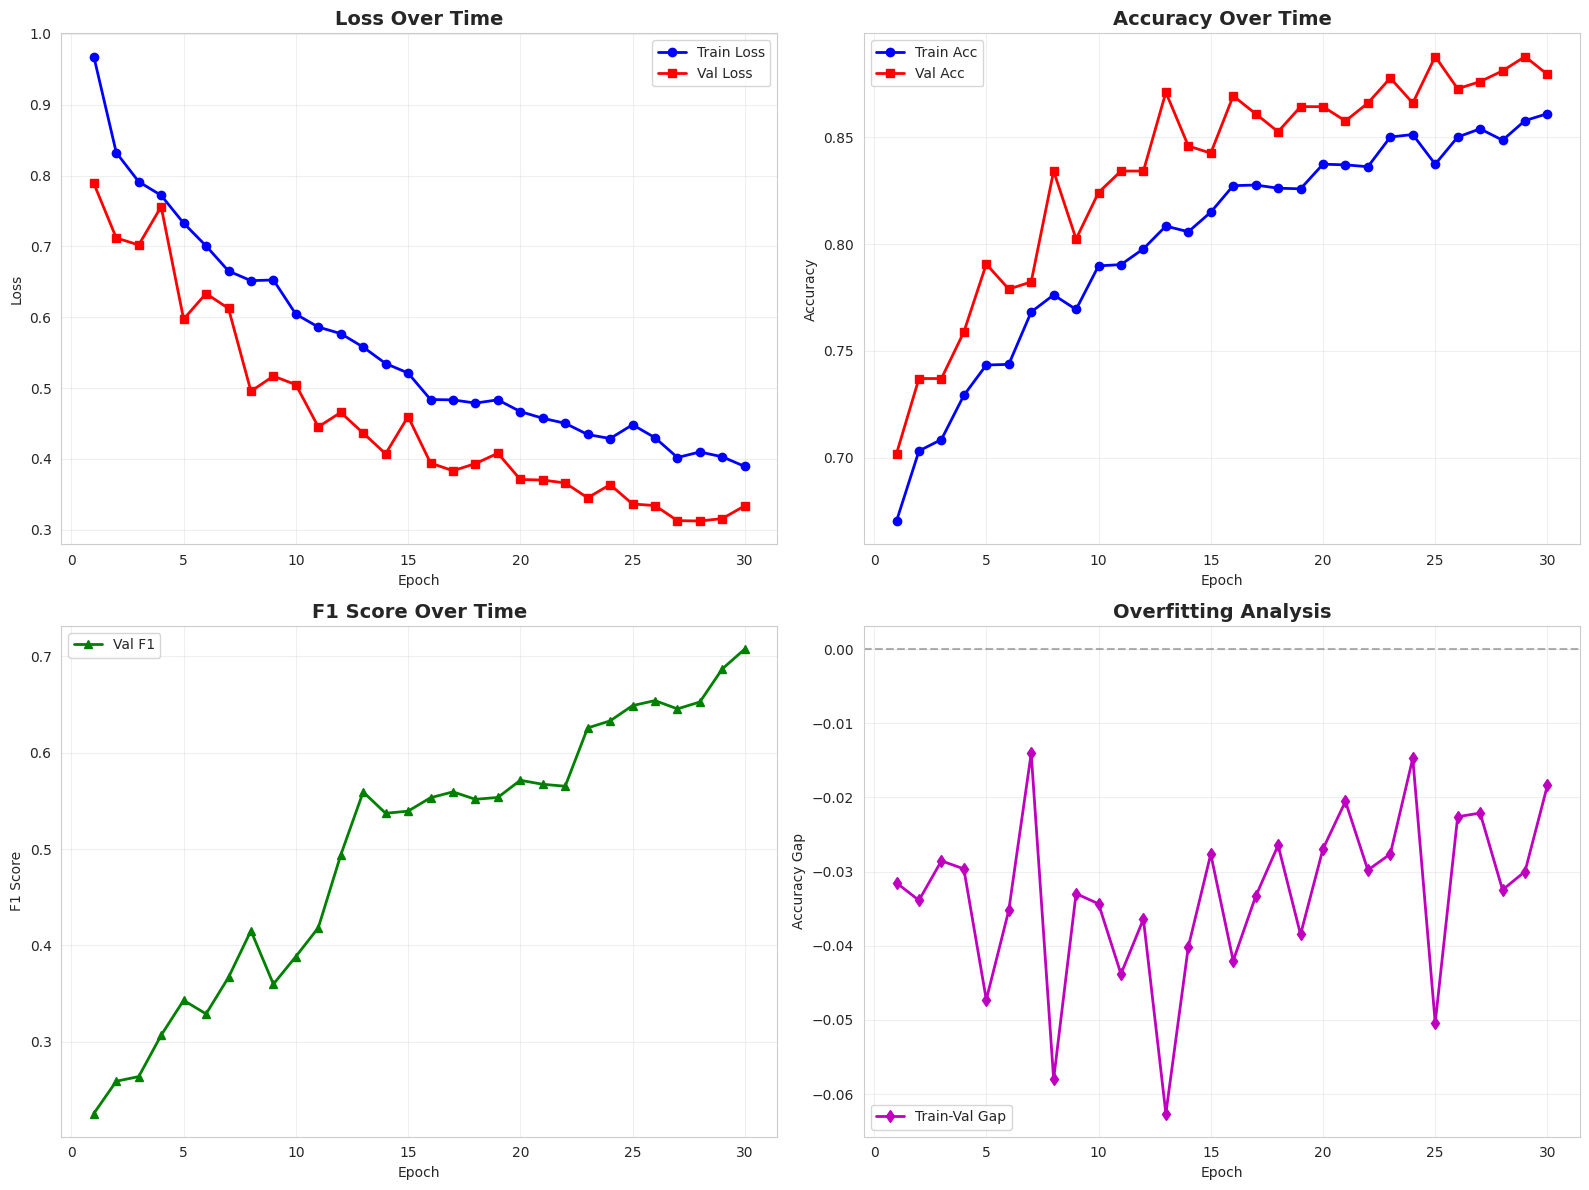


📊 Generating per-class metrics...


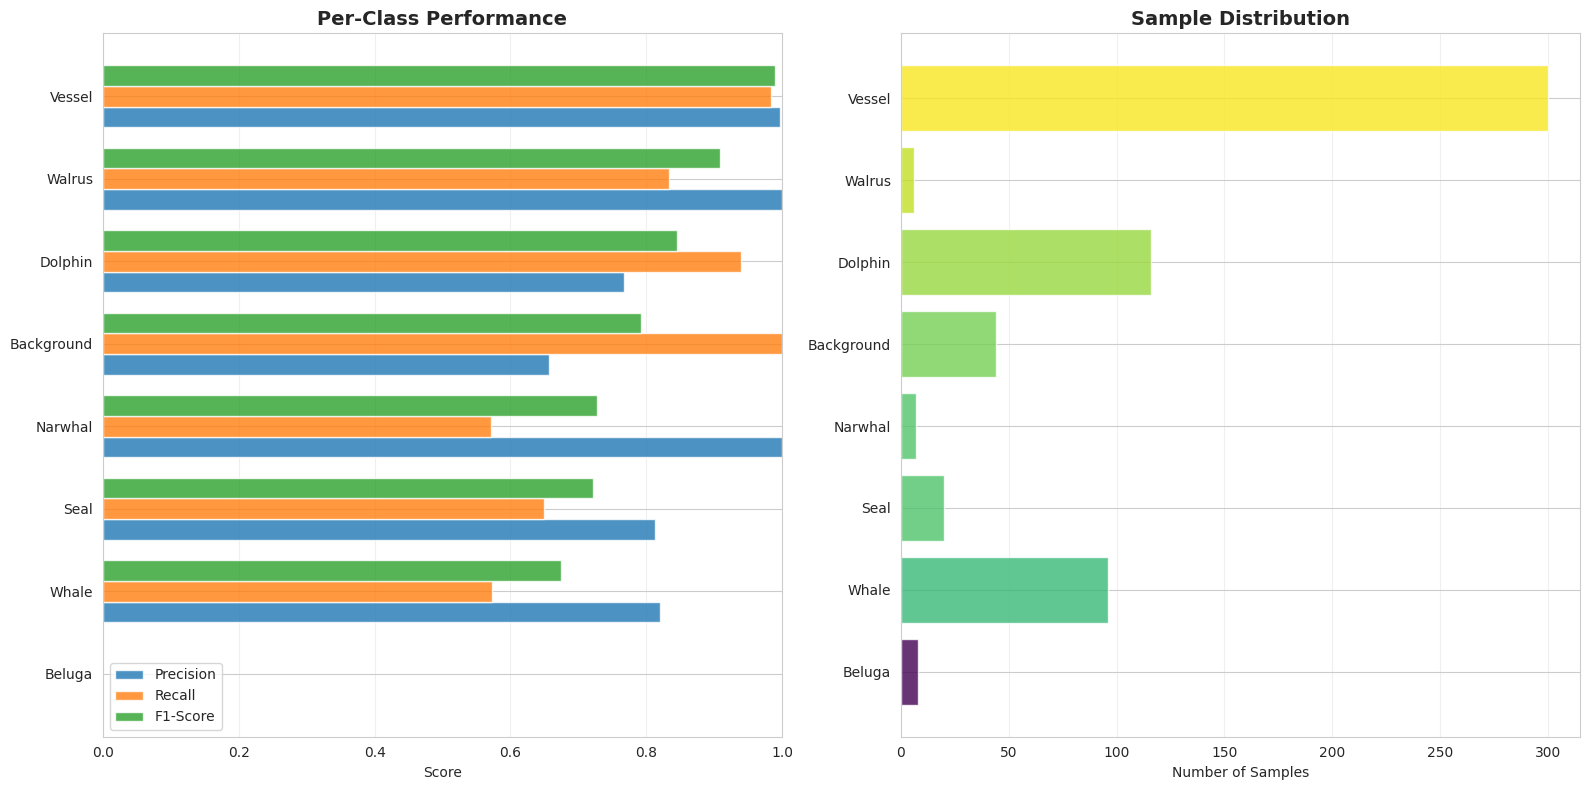


✅ ALL VISUALIZATIONS COMPLETE!

Generated files:
  ✓ best_family_classifier.pth
  ✓ family_confusion_matrix.png
  ✓ family_training_history.png
  ✓ family_per_class_metrics.png



In [26]:
# ============================================================
# COPY THIS ENTIRE CELL AND RUN IT - FAMILY CLASSIFIER
# This will train a model to classify into families, not individual species
# Expected accuracy: 70-85% (much better than 51% on species!)
# ============================================================

import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns

# ============ FUNCTION: CREATE FAMILY LABELS ============

def create_family_mappings(df):
    """Map species to families"""
    
    whale_species = [
        'Humpback Whale', 'Sperm Whale', 'Bowhead Whale', 
        'Fin_ Finback Whale', 'Minke Whale', 'Killer Whale',
        'Northern Right Whale', 'Southern Right Whale',
        'Long-Finned Pilot Whale', 'Short-Finned _Pacific_ Pilot Whale',
        'Melon Headed Whale', 'False Killer Whale'
    ]
    
    dolphin_species = [
        'Spinner Dolphin', "Fraser_s Dolphin", 'Striped Dolphin',
        'Pantropical Spotted Dolphin', 'Atlantic Spotted Dolphin',
        'Common Dolphin', 'Bottlenose Dolphin', 'Clymene Dolphin',
        'Rough-Toothed Dolphin', "Grampus_ Risso_s Dolphin",
        'White-beaked Dolphin', 'White-sided Dolphin'
    ]
    
    seal_species = [
        'Ross Seal', 'Harp Seal', 'Bearded Seal', 
        'Leopard Seal', 'Weddell Seal'
    ]
    
    vessel_types = [
        'Small vessels', 'Medium vessels', 'Large vessels', 'Passenger ferries'
    ]
    
    def get_family(class_name):
        if class_name in whale_species:
            return 'Whale'
        elif class_name in dolphin_species:
            return 'Dolphin'
        elif class_name in seal_species:
            return 'Seal'
        elif class_name in vessel_types:
            return 'Vessel'
        elif class_name == 'Walrus':
            return 'Walrus'
        elif class_name == 'Beluga_ White Whale':
            return 'Beluga'
        elif class_name == 'Narwhal':
            return 'Narwhal'
        elif class_name == 'Background Noise':
            return 'Background'
        else:
            return 'Unknown'
    
    df['family'] = df['class'].apply(get_family)
    return df

# ============ FUNCTION: PRECOMPUTE SPECTROGRAMS ============

def precompute_spectrograms(df, save_dir, duration=5000, sr=16000):
    os.makedirs(save_dir, exist_ok=True)
    print(f"Precomputing spectrograms to {save_dir}/...")
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio"):
        try:
            sig, orig_sr = torchaudio.load(row['path'])
            if orig_sr != sr:
                sig = T.Resample(orig_sr, sr)(sig)
            if sig.shape[0] > 1:
                sig = sig.mean(dim=0, keepdim=True)
            
            max_len = sr // 1000 * duration
            if sig.shape[1] > max_len:
                sig = sig[:, :max_len]
            elif sig.shape[1] < max_len:
                pad_len = max_len - sig.shape[1]
                sig = torch.nn.functional.pad(sig, (0, pad_len))
            
            mel_spec = T.MelSpectrogram(
                sample_rate=sr, n_fft=1024, hop_length=512, n_mels=64
            )(sig)
            mel_spec = T.AmplitudeToDB(top_db=80)(mel_spec)
            
            save_path = os.path.join(save_dir, f'{idx}.npy')
            np.save(save_path, mel_spec.numpy())
        except Exception as e:
            print(f"Error: {e}")
            continue
    
    df['spec_path'] = df.index.map(lambda x: os.path.join(save_dir, f'{x}.npy'))
    return df

# ============ DATASET CLASS ============

class PrecomputedSpectrogramDataset(torch.utils.data.Dataset):
    def __init__(self, df, label_column='family_id', is_train=True):
        self.df = df
        self.label_column = label_column
        self.is_train = is_train
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = np.load(row['spec_path'])
        spec = torch.FloatTensor(spec)
        
        if self.is_train:
            if torch.rand(1) > 0.5:
                spec = T.TimeMasking(time_mask_param=10)(spec)
            if torch.rand(1) > 0.5:
                spec = T.FrequencyMasking(freq_mask_param=8)(spec)
        
        label = torch.tensor(row[self.label_column], dtype=torch.long)
        return spec, label

# ============ MODEL ARCHITECTURE ============

class FamilyClassifierCNN(nn.Module):
    """Better model for family classification"""
    
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

# ============ TRAINING FUNCTION ============

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=30):
    best_val_f1 = 0.0
    patience = 7
    patience_counter = 0
    
    # Track history for visualization
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1': []
    }
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        
        # Track history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), 'best_family_classifier.pth')
            print(f"  ✓ Best model saved! Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    return history, all_labels, all_preds

# ============================================================
# MAIN EXECUTION - FAMILY CLASSIFIER
# ============================================================

print("=" * 70)
print("HIERARCHICAL FAMILY CLASSIFIER")
print("Instead of 37 species, we classify into ~7 families")
print("=" * 70)

# 1. Prepare data with family labels
print("\n1. Creating family mappings...")
data_with_families = create_family_mappings(filtered_data.copy())

# Show distribution
print("\nFamily Distribution:")
family_counts = data_with_families['family'].value_counts()
for family, count in family_counts.items():
    print(f"  {family:25s}: {count:4d} samples")

# 2. Encode labels
print("\n2. Encoding labels...")
le_family = LabelEncoder()
data_with_families['family_id'] = le_family.fit_transform(data_with_families['family'])

print(f"Number of families: {len(le_family.classes_)}")
print(f"Families: {list(le_family.classes_)}")

# 3. Split data
print("\n3. Creating train/val split...")
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(splitter.split(data_with_families, data_with_families['family_id']))

train_df = data_with_families.iloc[train_idx].reset_index(drop=True)
val_df = data_with_families.iloc[val_idx].reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")

# 4. Precompute spectrograms
print("\n4. Precomputing spectrograms (this will take a few minutes)...")
train_df = precompute_spectrograms(train_df, save_dir='family_train_specs', duration=5000, sr=16000)
val_df = precompute_spectrograms(val_df, save_dir='family_val_specs', duration=5000, sr=16000)

# 5. Create datasets
print("\n5. Creating datasets...")
train_ds = PrecomputedSpectrogramDataset(train_df, label_column='family_id', is_train=True)
val_ds = PrecomputedSpectrogramDataset(val_df, label_column='family_id', is_train=False)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=False
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=False
)

# 6. Initialize model
print("\n6. Initializing model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FamilyClassifierCNN(num_classes=len(le_family.classes_)).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 7. Train
print("\n7. Training Family Classifier...")
print("-" * 70)
history, final_labels, final_preds = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, num_epochs=30
)

# 8. Final evaluation
print("\n" + "=" * 70)
print("FINAL RESULTS - FAMILY CLASSIFIER")
print("=" * 70)

model.load_state_dict(torch.load('best_family_classifier.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")

print("\nPer-Family Classification Report:")
print(classification_report(all_labels, all_preds, target_names=le_family.classes_, zero_division=0))

# 9. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-7)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_family.classes_, yticklabels=le_family.classes_,
            cbar_kws={'label': 'Recall'})
plt.title('Family Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Family', fontsize=12)
plt.xlabel('Predicted Family', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('family_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print(f"Model saved to: best_family_classifier.pth")
print(f"Confusion matrix saved to: family_confusion_matrix.png")
print("=" * 70)

# ============================================================
# STEP 10: GENERATE ALL ADDITIONAL VISUALIZATIONS
# ============================================================

print("\n" + "🎨"*35)
print("GENERATING COMPREHENSIVE VISUALIZATIONS")
print("🎨"*35)

# Training history plots
print("\n📊 Generating training history plots...")
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
axes[0, 0].set_title('Loss Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-s', label='Val Acc', linewidth=2)
axes[0, 1].set_title('Accuracy Over Time', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot(epochs_range, history['val_f1'], 'g-^', label='Val F1', linewidth=2)
axes[1, 0].set_title('F1 Score Over Time', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Overfitting Gap
train_val_gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(epochs_range, train_val_gap, 'm-d', label='Train-Val Gap', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Gap')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('family_training_history.png', bbox_inches='tight', dpi=300)
plt.show()

# Per-class performance
print("\n📊 Generating per-class metrics...")
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_scores, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=range(len(le_family.classes_)), zero_division=0
)

metrics_df = pd.DataFrame({
    'Class': le_family.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_scores,
    'Support': support
}).sort_values('F1-Score', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(le_family.classes_) * 0.5)))

# Performance bars
x = np.arange(len(metrics_df))
width = 0.25

axes[0].barh(x - width, metrics_df['Precision'], width, label='Precision', alpha=0.8)
axes[0].barh(x, metrics_df['Recall'], width, label='Recall', alpha=0.8)
axes[0].barh(x + width, metrics_df['F1-Score'], width, label='F1-Score', alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(metrics_df['Class'])
axes[0].set_xlabel('Score')
axes[0].set_title('Per-Class Performance', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

# Support bars
colors = plt.cm.viridis(metrics_df['F1-Score'])
axes[1].barh(x, metrics_df['Support'], color=colors, alpha=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels(metrics_df['Class'])
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('Sample Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('family_per_class_metrics.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n" + "="*70)
print("✅ ALL VISUALIZATIONS COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  ✓ best_family_classifier.pth")
print("  ✓ family_confusion_matrix.png")
print("  ✓ family_training_history.png")
print("  ✓ family_per_class_metrics.png")
print("\n" + "="*70)